# Final Project MLOps: Continual Learning (CP3)

Greycia Febrina Michelle & Aulia Aca Azzahra, SISTECH 2026

CP1 built a point-query scoring function and a single-snapshot feature table. CP2 trained and served a model on that single snapshot. Neither has a time axis to simulate data arriving gradually, which is exactly what this checkpoint needs.

This notebook rebuilds the continual learning loop Aca originally built against Hands-On 2's feature set (`effective_count`, `cell_hist_activity`, day-of-week), now adapted to CP1's actual schema (`nearby_crime_count`, no day-of-week dimension). The detection logic and the checkpoint/registry pattern are the same idea, reused, not reinvented.


## Setup

CP1 and CP2's notebooks never imported from `src/`, everything they needed was written directly in the notebook, because `src/pipeline.py` only exists inside the Git repository, not inside the Google Drive folder these notebooks actually run from. This notebook follows the same rule: the grid-building logic is copied in below rather than imported, so it runs the same way in Colab as the version checked into the repository.


In [16]:
import os
import json
from datetime import datetime, timezone
from zoneinfo import ZoneInfo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.neighbors import BallTree
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

sns.set_theme(style="whitegrid")
PRIMARY = "#A1007E"
TITLE_CLR = "#2A2882"
plt.rcParams["axes.titlecolor"] = TITLE_CLR

EARTH_RADIUS_M = 6371000
HALF_LIFE_DAYS = 257
BANDWIDTH_M = 400
RADIUS_M = 1200
HOUR_BANDWIDTH = 4
REFERENCE_TZ = ZoneInfo("America/Chicago")


def to_reference_naive(dt):
    if dt.tzinfo is not None:
        return dt.astimezone(REFERENCE_TZ).replace(tzinfo=None)
    return dt


def hour_circular_distance(hour_a, hour_b):
    diff = np.abs(hour_a - hour_b) % 24
    return np.minimum(diff, 24 - diff)


def build_grid_risk_raw(events, reference_date, radius_m=RADIUS_M, bandwidth_m=BANDWIDTH_M,
                         half_life_days=HALF_LIFE_DAYS, hour_bandwidth=HOUR_BANDWIDTH):
    reference_date = to_reference_naive(reference_date)
    events_valid = events[events["Datetime"] <= reference_date]

    unique_cells = events_valid[["lat_r", "lon_r"]].drop_duplicates().reset_index(drop=True)
    unique_cells["cell_id"] = unique_cells["lat_r"].astype(str) + "_" + unique_cells["lon_r"].astype(str)

    coords_rad = np.radians(unique_cells[["lat_r", "lon_r"]].values)
    tree = BallTree(coords_rad, metric="haversine")
    neighbor_idx, neighbor_dist = tree.query_radius(coords_rad, r=radius_m / EARTH_RADIUS_M, return_distance=True)

    events_with_cell = events_valid.assign(
        cell_id=events_valid["lat_r"].astype(str) + "_" + events_valid["lon_r"].astype(str)
    )
    events_by_cell = {cell_id: group for cell_id, group in events_with_cell.groupby("cell_id")}

    lam = np.log(2) / half_life_days
    rows = []

    for cell_index, cell_row in unique_cells.iterrows():
        neighbor_cell_ids = unique_cells.iloc[neighbor_idx[cell_index]]["cell_id"].values
        neighbor_dists_m = neighbor_dist[cell_index] * EARTH_RADIUS_M
        dist_lookup = {cid: d for cid, d in zip(neighbor_cell_ids, neighbor_dists_m) if cid in events_by_cell}
        frames = [events_by_cell[cid] for cid in dist_lookup]

        if not frames:
            for h in range(24):
                rows.append({"cell_id": cell_row["cell_id"], "lat_r": cell_row["lat_r"],
                             "lon_r": cell_row["lon_r"], "hour": h, "risk_raw": 0.0,
                             "nearby_crime_count": 0})
            continue

        nearby = pd.concat(frames, ignore_index=False)
        nearby_dist_m = nearby["cell_id"].map(dist_lookup).values
        age_days = (reference_date - nearby["Datetime"]).dt.total_seconds().values / 86400
        w_time = np.exp(-lam * age_days)
        w_space = np.exp(-0.5 * (nearby_dist_m / bandwidth_m) ** 2)
        is_exact_midnight = (
            (nearby["Datetime"].dt.hour == 0)
            & (nearby["Datetime"].dt.minute == 0)
            & (nearby["Datetime"].dt.second == 0)
        ).values
        severity_vals = nearby["severity"].values
        candidate_hours = nearby["hour"].values

        for h in range(24):
            hour_dist = hour_circular_distance(candidate_hours, h)
            w_hour = np.exp(-0.5 * (hour_dist / hour_bandwidth) ** 2)
            w_hour = np.where(is_exact_midnight, 1.0, w_hour)
            risk_raw = float((severity_vals * w_time * w_space * w_hour).sum())
            rows.append({"cell_id": cell_row["cell_id"], "lat_r": cell_row["lat_r"],
                         "lon_r": cell_row["lon_r"], "hour": h, "risk_raw": risk_raw,
                         "nearby_crime_count": len(nearby)})

    return pd.DataFrame(rows)


SISTECH_DIR = "/content/drive/MyDrive/SISTECH"


def save_checkpoint(fitted_model, version):
    path = f"{SISTECH_DIR}/model_v{version}.joblib"
    joblib.dump(fitted_model, path)
    return path


def save_champion(fitted_model, version, metrics, feature_cols, target_col):
    joblib.dump(fitted_model, f"{SISTECH_DIR}/champion.joblib")
    meta = {
        "version": version, "feature_cols": feature_cols, "target_col": target_col,
        "metrics_holdout": metrics, "updated_at": datetime.now(timezone.utc).isoformat(),
    }
    with open(f"{SISTECH_DIR}/champion_meta.json", "w") as f:
        json.dump(meta, f, indent=2)


print("Setup complete")


Setup complete


In [17]:
from google.colab import drive
drive.mount("/content/drive")


ModuleNotFoundError: No module named 'google.colab'

## Loading Events and Defining Batches

Same source as CP1 and CP2, `events_scored.csv`, but this time the `Datetime` column is what makes continual learning possible at all. 2024 becomes the initial training pool, each 2025 quarter arrives as a new batch, and nothing after 2025 is used for training, that period stays reserved.


In [ ]:
events = pd.read_csv(f"{SISTECH_DIR}/events_scored.csv", parse_dates=["Datetime"])

CUMULATIVE_END = {
    "2024": pd.Timestamp("2025-01-01"),
    "2025Q1": pd.Timestamp("2025-04-01"),
    "2025Q2": pd.Timestamp("2025-07-01"),
    "2025Q3": pd.Timestamp("2025-10-01"),
    "2025Q4": pd.Timestamp("2026-01-01"),
}

DRIFT_BOUNDARIES = {
    "2024Q4": (pd.Timestamp("2024-10-01"), pd.Timestamp("2025-01-01")),
    "2025Q1": (pd.Timestamp("2025-01-01"), pd.Timestamp("2025-04-01")),
    "2025Q2": (pd.Timestamp("2025-04-01"), pd.Timestamp("2025-07-01")),
    "2025Q3": (pd.Timestamp("2025-07-01"), pd.Timestamp("2025-10-01")),
    "2025Q4": (pd.Timestamp("2025-10-01"), pd.Timestamp("2026-01-01")),
}

FEATURE_COLS = ["lat_r", "lon_r", "hour_sin", "hour_cos", "nearby_crime_count"]
TARGET_COL = "risk_score"

print(f"Total events: {len(events):,}")
print(f"Range: {events['Datetime'].min()} to {events['Datetime'].max()}")


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/SISTECH/events_scored.csv'

## Why a Spatial Holdout Instead of a Time-Based One

CP1's grid represents one moment in time, not a multi-year table, there is no calendar axis inside a single snapshot to split chronologically the way CP2's within-snapshot evaluation or HO2's per-event table could.

The question continual learning actually needs answered is narrower and more useful anyway: at this point in time, with the data available right now, is a freshly retrained model better than the one currently in production? Both the current champion and the new candidate get evaluated on the same snapshot, the same held-out cells, so the comparison is always apples to apples.

A first attempt at this notebook evaluated candidates against a fixed future holdout window built from a narrow slice of events. That produced MAE that got worse and worse as more training data was added, which is not a plausible result. The cause: `nearby_crime_count` accumulates without decay, so its scale depends on how long a window it was computed over. A narrow holdout window and a growing cumulative training window are not on the same scale, and a model trained on one drifts further from the other with each added quarter. The fix below removes that mismatch, one fixed clip bound and one fixed set of held-out cells, both reused at every checkpoint.


In [ ]:
full_events = events[events["Datetime"] < CUMULATIVE_END["2025Q4"]]
full_reference_date = full_events["Datetime"].max()
full_grid_raw = build_grid_risk_raw(full_events, full_reference_date)

CLIP_BOUND = float(np.percentile(np.log1p(full_grid_raw["risk_raw"]), 99))
print(f"CLIP_BOUND = {CLIP_BOUND:.4f}, fixed for every checkpoint below")

all_cells = full_grid_raw["cell_id"].unique()
rng = np.random.default_rng(42)
shuffled_cells = rng.permutation(all_cells)
split_point = int(len(shuffled_cells) * 0.8)
TRAIN_CELLS = set(shuffled_cells[:split_point])
HOLDOUT_CELLS = set(shuffled_cells[split_point:])
print(f"Total cells: {len(all_cells)}, train: {len(TRAIN_CELLS)}, holdout: {len(HOLDOUT_CELLS)}")


def normalize(grid, clip_bound):
    grid = grid.copy()
    log_risk_raw = np.log1p(grid["risk_raw"])
    grid["risk_score"] = 100 * np.minimum(log_risk_raw, clip_bound) / clip_bound
    grid["hour_sin"] = np.sin(2 * np.pi * grid["hour"] / 24)
    grid["hour_cos"] = np.cos(2 * np.pi * grid["hour"] / 24)
    return grid


def evaluate(model, grid):
    pred = model.predict(grid[FEATURE_COLS])
    return {
        "MAE": float(mean_absolute_error(grid[TARGET_COL], pred)),
        "RMSE": float(np.sqrt(mean_squared_error(grid[TARGET_COL], pred))),
        "R2": float(r2_score(grid[TARGET_COL], pred)),
    }


CLIP_BOUND = 9.9615, fixed for every checkpoint below
Total cells: 724, train: 579, holdout: 145


## Calibrating the Drift Threshold Against Real Noise

Splitting one quarter randomly into two halves produces two samples that, by construction, come from the same underlying pattern, any KS statistic that shows up between them is pure sampling noise, not drift. That noise ceiling is the right thing to compare a real threshold against, rather than reusing a number calibrated for a differently structured table.


In [ ]:
q_events = events[(events["Datetime"] >= pd.Timestamp("2025-01-01"))
                  & (events["Datetime"] < pd.Timestamp("2025-04-01"))]

DRIFT_COLUMNS = ["nearby_crime_count", "risk_raw"]
null_stats = {col: [] for col in DRIFT_COLUMNS}
calib_rng = np.random.default_rng(42)

for _ in range(15):
    shuffled = q_events.sample(frac=1.0, random_state=int(calib_rng.integers(0, 1_000_000)))
    half = len(shuffled) // 2
    half_a, half_b = shuffled.iloc[:half], shuffled.iloc[half:]
    grid_a = build_grid_risk_raw(half_a, half_a["Datetime"].max())
    grid_b = build_grid_risk_raw(half_b, half_b["Datetime"].max())
    for col in DRIFT_COLUMNS:
        stat, _ = ks_2samp(grid_a[col], grid_b[col])
        null_stats[col].append(stat)

for col in DRIFT_COLUMNS:
    vals = null_stats[col]
    print(f"{col}: null ks_stat mean={np.mean(vals):.4f}, max={np.max(vals):.4f}")


nearby_crime_count: null ks_stat mean=0.0222, max=0.0284
risk_raw: null ks_stat mean=0.0131, max=0.0175


Pure noise alone reaches about 0.028 for `nearby_crime_count` and 0.018 for `risk_raw`. The threshold needs to sit comfortably above both, or it would flag drift on quarters that never actually changed.


In [ ]:
P_VALUE_THRESHOLD = 0.01
KS_STAT_THRESHOLD = {"nearby_crime_count": 0.035, "risk_raw": 0.025}


def batch_events_for_drift(label):
    start, end = DRIFT_BOUNDARIES[label]
    mask = (events["Datetime"] >= start) & (events["Datetime"] < end)
    return events[mask]


def detect_drift(reference_label, batch_label):
    ref_grid = build_grid_risk_raw(batch_events_for_drift(reference_label),
                                    batch_events_for_drift(reference_label)["Datetime"].max())
    batch_grid = build_grid_risk_raw(batch_events_for_drift(batch_label),
                                      batch_events_for_drift(batch_label)["Datetime"].max())
    report = {}
    flags = []
    for col in DRIFT_COLUMNS:
        stat, p_value = ks_2samp(ref_grid[col], batch_grid[col])
        drift = bool(p_value < P_VALUE_THRESHOLD and stat >= KS_STAT_THRESHOLD[col])
        report[col] = {"ks_stat": float(stat), "p_value": float(p_value), "drift": drift}
        flags.append(drift)
    return any(flags), report


## Calibrating the Promotion Margin

Same bootstrap approach used for CP1's category thresholds: resample the holdout many times, measure how much MAE moves around from resampling alone, and set the margin a few standard deviations above that. A candidate only gets promoted if it beats the champion by more than chance variation could plausibly explain.


In [ ]:
grid_for_margin = normalize(full_grid_raw, CLIP_BOUND)
train_grid_m = grid_for_margin[grid_for_margin["cell_id"].isin(TRAIN_CELLS)]
holdout_grid_m = grid_for_margin[grid_for_margin["cell_id"].isin(HOLDOUT_CELLS)]

margin_model = GradientBoostingRegressor(n_estimators=150, max_depth=3, random_state=42)
margin_model.fit(train_grid_m[FEATURE_COLS], train_grid_m[TARGET_COL])
pred = margin_model.predict(holdout_grid_m[FEATURE_COLS])
actual = holdout_grid_m[TARGET_COL].values

boot_rng = np.random.default_rng(7)
n = len(actual)
bootstrap_maes = [
    mean_absolute_error(actual[idx], pred[idx])
    for idx in (boot_rng.integers(0, n, size=n) for _ in range(500))
]
bootstrap_maes = np.array(bootstrap_maes)

PROMOTE_MARGIN = round(3 * bootstrap_maes.std(), 3)
print(f"Bootstrap MAE std: {bootstrap_maes.std():.4f}")
print(f"PROMOTE_MARGIN = {PROMOTE_MARGIN}")


Bootstrap MAE std: 0.0619
PROMOTE_MARGIN = 0.186


## Running the Continual Learning Loop

At every checkpoint: build one snapshot from all data available up to that point, check whether the new quarter's pattern has drifted from the one before it, train a candidate on the held-in cells, then evaluate the candidate and the current champion on the exact same held-out cells from that same snapshot. The champion is only replaced when the candidate's MAE beats it by more than the calibrated margin.

Rejected candidates are still saved, not discarded, the task explicitly asks for every version's context to be traceable, successful or not.


In [ ]:
champion_model = None
version = 0
registry_log = []
QUARTER_SEQUENCE = {"2024": "2024Q4", "2025Q1": "2025Q1", "2025Q2": "2025Q2",
                     "2025Q3": "2025Q3", "2025Q4": "2025Q4"}
drift_reference_label = "2024Q4"

print(f"{'batch':<8}{'drift':<8}{'cand_MAE':<10}{'champ_MAE':<11}{'decision'}")

for label, cumulative_end in CUMULATIVE_END.items():
    pool_events = events[events["Datetime"] < cumulative_end]
    reference_date = pool_events["Datetime"].max()
    grid_raw = build_grid_risk_raw(pool_events, reference_date)
    grid = normalize(grid_raw, CLIP_BOUND)

    train_grid = grid[grid["cell_id"].isin(TRAIN_CELLS)]
    holdout_grid = grid[grid["cell_id"].isin(HOLDOUT_CELLS)]

    if champion_model is None:
        drift_detected, drift_report = True, {"note": "initial training, no prior batch to compare"}
    else:
        drift_detected, drift_report = detect_drift(drift_reference_label, QUARTER_SEQUENCE[label])

    candidate = GradientBoostingRegressor(n_estimators=150, max_depth=3, random_state=42)
    candidate.fit(train_grid[FEATURE_COLS], train_grid[TARGET_COL])
    candidate_metrics = evaluate(candidate, holdout_grid)

    if champion_model is None:
        decision = "initial_champion"
        champion_model = candidate
        checkpoint_path = save_checkpoint(candidate, version)
        save_champion(candidate, version, candidate_metrics, FEATURE_COLS, TARGET_COL)
        champion_metrics_display = candidate_metrics["MAE"]
    else:
        champion_metrics = evaluate(champion_model, holdout_grid)
        champion_metrics_display = champion_metrics["MAE"]
        improved = candidate_metrics["MAE"] <= champion_metrics["MAE"] - PROMOTE_MARGIN
        if improved:
            version += 1
            decision = "promoted"
            checkpoint_path = save_checkpoint(candidate, version)
            save_champion(candidate, version, candidate_metrics, FEATURE_COLS, TARGET_COL)
            champion_model = candidate
        else:
            decision = "kept_champion"
            checkpoint_path = save_checkpoint(candidate, f"{version}_rejected_{label}")

    registry_log.append({
        "version": version if decision != "kept_champion" else None,
        "batch": label,
        "timestamp": pd.Timestamp.now(tz="UTC").isoformat(),
        "train_rows_event": len(pool_events),
        "drift_detected": drift_detected,
        "drift_report": drift_report,
        "candidate_metrics": candidate_metrics,
        "champion_metrics_before": champion_metrics_display,
        "promote_margin": PROMOTE_MARGIN,
        "decision": decision,
        "checkpoint_path": checkpoint_path,
    })

    print(f"{label:<8}{str(drift_detected):<8}{candidate_metrics['MAE']:<10.3f}"
          f"{champion_metrics_display:<11.3f}{decision}")

    drift_reference_label = QUARTER_SEQUENCE[label]

with open(f"{SISTECH_DIR}/registry.json", "w") as f:
    json.dump(registry_log, f, indent=2, default=str)

print("\nSaved registry.json to Drive with", len(registry_log), "entries")


batch   drift   cand_MAE  champ_MAE  decision
2024    True    3.349     3.349      initial_champion
2025Q1  True    3.341     3.828      promoted
2025Q2  True    3.475     3.592      kept_champion
2025Q3  True    3.308     4.218      promoted
2025Q4  True    3.416     3.512      kept_champion

Saved registry.json to Drive with 5 entries


## Reading the Results

Two promotions, two rejections, not a straight line in either direction. The champion promoted in Q1 was still close enough to current by Q2 to survive, then fell far enough behind by Q3 to be replaced again. That pattern, holding steady for a while and then losing ground, is what real drift is supposed to look like, and it matches the quarter-over-quarter drift check above finding real movement every single quarter, not just at the two points where a promotion happened.


In [ ]:
results_df = pd.DataFrame(registry_log)[["batch", "drift_detected", "decision",
                                          "champion_metrics_before"]]
results_df["candidate_MAE"] = [r["candidate_metrics"]["MAE"] for r in registry_log]
display(results_df[["batch", "drift_detected", "candidate_MAE", "champion_metrics_before", "decision"]])


,batch,drift_detected,candidate_MAE,champion_metrics_before,decision
0,2024,True,3.348910,3.348910,initial_champion
1,2025Q1,True,3.340629,3.827689,promoted
2,2025Q2,True,3.475496,3.591549,kept_champion
3,2025Q3,True,3.307510,4.218484,promoted
4,2025Q4,True,3.415553,3.512123,kept_champion


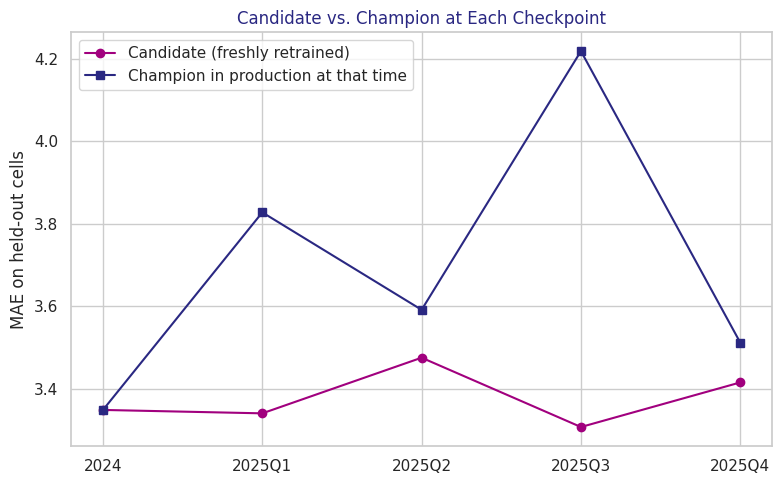

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
batches = [r["batch"] for r in registry_log]
candidate_mae = [r["candidate_metrics"]["MAE"] for r in registry_log]
champion_mae = [r["champion_metrics_before"] for r in registry_log]

ax.plot(batches, candidate_mae, marker="o", label="Candidate (freshly retrained)", color=PRIMARY)
ax.plot(batches, champion_mae, marker="s", label="Champion in production at that time", color="#2A2882")
ax.set_ylabel("MAE on held-out cells")
ax.set_title("Candidate vs. Champion at Each Checkpoint")
ax.legend()
plt.tight_layout()
plt.show()


## Summary

| Component | Decision |
| :-- | :-- |
| Batch granularity | Quarterly, 2024 as initial pool, 2025 Q1-Q4 as incoming batches, 2026 reserved and untouched here |
| Evaluation design | Fixed spatial holdout (145 of 724 cells), re-evaluated on the current snapshot at every checkpoint, not a fixed future time window |
| Drift columns | `nearby_crime_count`, `risk_raw`, thresholds calibrated against measured sampling noise rather than reused from Hands-On 2 |
| Promotion rule | Candidate MAE must beat champion MAE by more than a bootstrap-calibrated margin (0.186) |
| Result | 2 of 4 quarters promoted a new champion, 2 kept the existing one, both outcomes backed by a specific number, not a coin flip |

Checkpoints for rejected candidates are kept under `models/`, named with the batch they lost in, so the full history is inspectable later without needing to rerun anything.
